In [1]:
import numpy as np
import matplotlib.pyplot as plt
from grid_cells.random_walk import generate_bat_flight

In [2]:
T = 100
dt = 0.5e-3
bat_flight = generate_bat_flight(
    T=T,
    dt=dt,
)

100%|██████████| 199999/199999 [00:15<00:00, 13134.24it/s]


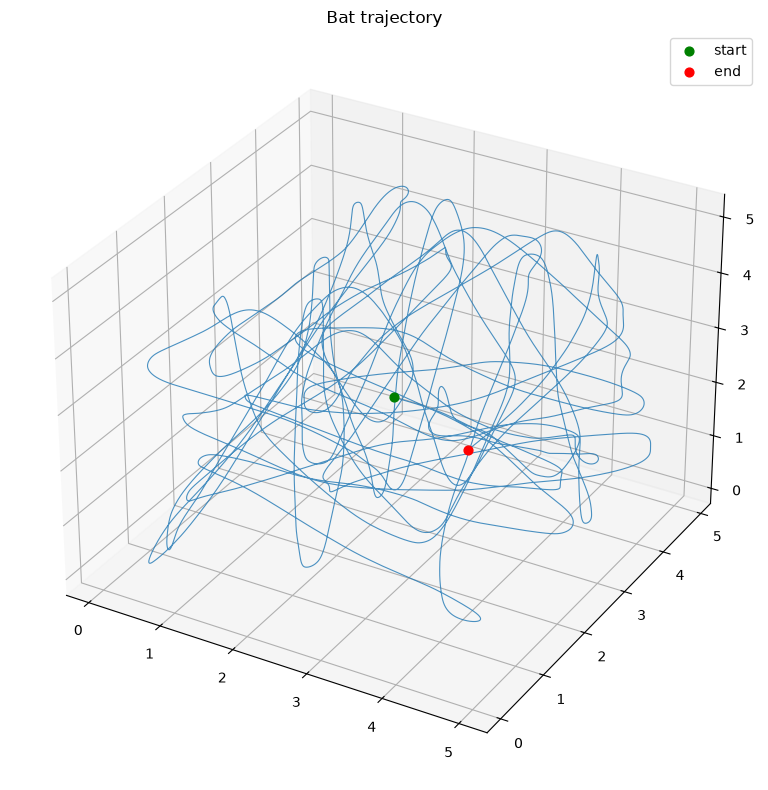

In [3]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection="3d")

speed_mask = np.linalg.norm(bat_flight["vel"], axis=-1) > 1.2

pos = bat_flight["pos"]
traj = pos

ax.plot(traj[:, 0], traj[:, 1], traj[:, 2], lw=0.8, alpha=0.8, color="tab:blue")
ax.scatter(traj[0, 0], traj[0, 1], traj[0, 2], color="green", s=40, label="start")
ax.scatter(traj[-1, 0], traj[-1, 1], traj[-1, 2], color="red", s=40, label="end")

ax.set_title("Bat trajectory")
ax.legend()
plt.tight_layout()
plt.show()

In [4]:
np.min(bat_flight["pos"]), np.max(bat_flight["pos"])

(np.float64(0.043838641138244004), np.float64(5.039627368808104))

In [5]:
np.min(bat_flight["dir_vel"][speed_mask], axis=0), np.max(
    bat_flight["dir_vel"][speed_mask], axis=0
)

(array([-19.99998857, -20.        ]), array([19.9999985 , 19.99999969]))

In [6]:
(np.linalg.norm(bat_flight["vel"], axis=-1) < 1.2).mean()

np.float64(0.020525)

(array([0.02174164, 0.21392261, 0.40317725, 0.43239606, 0.3736914 ,
        0.28770399, 0.20339672, 0.15243627, 0.0860653 , 0.0508158 ]),
 array([0.50631885, 0.95568697, 1.40505508, 1.8544232 , 2.30379131,
        2.75315943, 3.20252754, 3.65189566, 4.10126377, 4.55063189,
        5.        ]),
 <BarContainer object of 10 artists>)

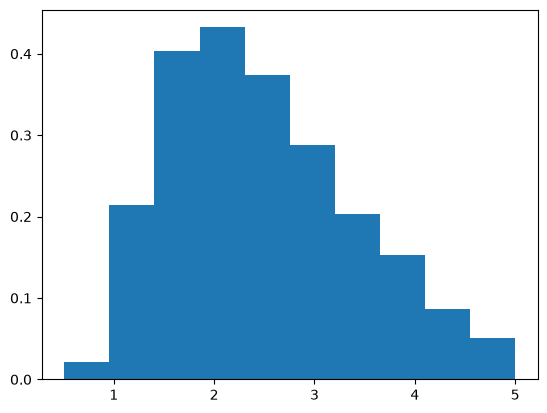

In [7]:
plt.hist(np.linalg.norm(bat_flight["vel"], axis=-1), density=True)